### Importing all required libraries

In [1]:
# !pip uninstall flwr -y
# !pip install flwr==1.7.0

In [2]:
import os
import glob
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, BatchNormalization, Dropout, Concatenate,
    GlobalAveragePooling2D, Conv2D, MaxPooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.utils import Sequence
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import flwr as fl

warnings.filterwarnings("ignore")

print("All libraries imported successfully")
print("Flower version:", fl.__version__)
print("TensorFlow version:", tf.__version__)

All libraries imported successfully
Flower version: 1.7.0
TensorFlow version: 2.19.0


### Kaggle setup

In [3]:
if not os.path.exists('/root/.kaggle'):
    os.makedirs('/root/.kaggle')

!mv kaggle.json /root/.kaggle/ 2>/dev/null || true
!chmod 600 /root/.kaggle/kaggle.json 2>/dev/null || true

### Extracting dataset from kaggle

In [4]:
!kaggle datasets download -d mehradaria/leukemia -p /content/

with zipfile.ZipFile('/content/leukemia.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/A_Raw/')

Dataset URL: https://www.kaggle.com/datasets/mehradaria/leukemia
License(s): ODbL-1.0
100% 110M/110M [00:00<00:00, 125MB/s]



### Structuring folder

In [5]:
base_path = '/content/Institution_Alpha'
os.makedirs(f'{base_path}/Healthy',   exist_ok=True)
os.makedirs(f'{base_path}/Leukemia',  exist_ok=True)

In [6]:
for p in glob.glob('/content/A_Raw/**/Benign/*.*', recursive=True):
    shutil.copy(p, f'{base_path}/Healthy/')

for sub in ['Early', 'Pre', 'Pro']:
    for p in glob.glob(f'/content/A_Raw/**/{sub}/*.*', recursive=True):
        shutil.copy(p, f'{base_path}/Leukemia/')

print(f"Institution Alpha Ready: {len(os.listdir(base_path+'/Healthy'))} Healthy, " f"{len(os.listdir(base_path+'/Leukemia'))} Leukemia images.")


Institution Alpha Ready: 504 Healthy, 2752 Leukemia images.


### Importing Clinical Data

In [8]:
df_a = pd.read_csv('/content/hospital_A_clinical.csv')

In [9]:
def remap_path(old_path):
    filename = os.path.basename(old_path)

    for prefix in ['A_Pre_', 'A_Early_', 'A_Pro_', 'A_Benign_', 'A_H_', 'A_L_']:
        if filename.startswith(prefix):
            filename = filename.replace(prefix, '')
            break

    subfolder = 'Healthy' if ('Healthy' in old_path or '_H_' in filename or 'Benign' in old_path) else 'Leukemia'

    return f'/content/Institution_Alpha/{subfolder}/{filename}'

In [10]:
df_a['image_path'] = df_a['image_path'].apply(remap_path)

In [11]:
valid_paths = df_a['image_path'].apply(os.path.exists)
missing_count = (~valid_paths).sum()

if missing_count > 0:
    print(f"Warning: {missing_count} images not found on disk. Dropping missing rows...")
    df_a = df_a[valid_paths].reset_index(drop=True)
else:
    print("All CSV image paths successfully verified.")

print(f"Total valid patients locked in for training: {len(df_a)}")

All CSV image paths successfully verified.
Total valid patients locked in for training: 3256


In [12]:
features = ['WBC_count', 'Blast_percentage', 'LDH_level', 'Hemoglobin', 'Platelet_count',
            'RBC_count', 'Hematocrit', 'Lymphocyte_percentage', 'Neutrophil_percentage', 'Uric_acid']

### Scaling tabular data

In [13]:
scaler = StandardScaler()
df_a[features] = scaler.fit_transform(df_a[features])

### Spliting data into train and test

In [14]:
train_df, temp_df = train_test_split(
    df_a,
    test_size=0.3,
    random_state=42,
    stratify=df_a['Diagnosis']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['Diagnosis']
)

print(f"Institution Alpha Ready: {len(train_df)} train rows, {len(val_df)} val rows, {len(test_df)} test rows.")

Institution Alpha Ready: 2279 train rows, 488 val rows, 489 test rows.


### Data Agumentation

In [15]:
aug = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

### THE MULTIMODAL DATA ENGINE

In [18]:
class LeukemiaDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, dataframe, batch_size=32, target_size=(224, 224),
                 shuffle=True, is_training=True, mixup_alpha=0.2):
        self.df           = dataframe.reset_index(drop=True)
        self.batch_size   = batch_size
        self.target_size  = target_size
        self.shuffle      = shuffle
        self.is_training  = is_training
        self.mixup_alpha  = mixup_alpha
        self.features     = ['WBC_count', 'Blast_percentage', 'LDH_level', 'Hemoglobin', 'Platelet_count',
                             'RBC_count', 'Hematocrit', 'Lymphocyte_percentage', 'Neutrophil_percentage', 'Uric_acid']
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

    def _mixup_tabular(self, X_tab, y):
        lam     = np.random.beta(self.mixup_alpha, self.mixup_alpha)
        idx     = np.random.permutation(len(X_tab))
        X_mixed = lam * X_tab + (1 - lam) * X_tab[idx]
        y_mixed = lam * y     + (1 - lam) * y[idx]
        return X_mixed, y_mixed

    def __getitem__(self, index):
        batch = self.df.iloc[index * self.batch_size : (index + 1) * self.batch_size]

        images = []
        for p in batch['image_path']:
            img = img_to_array(load_img(p, target_size=self.target_size)) / 255.0
            if self.is_training:
                img = aug.random_transform(img)
            images.append(img)
        X_img = np.array(images)

        X_tab = batch[self.features].values.astype(np.float32)
        y     = batch['Diagnosis'].values.astype(np.float32)

        if self.is_training:
            X_tab, y = self._mixup_tabular(X_tab, y)

        return (X_img, X_tab), y

In [19]:
train_gen = LeukemiaDataGenerator(train_df, batch_size=32, is_training=True,  mixup_alpha=0.2)
val_gen   = LeukemiaDataGenerator(val_df,   batch_size=32, is_training=False, shuffle=False)
test_gen  = LeukemiaDataGenerator(test_df,  batch_size=32, is_training=False, shuffle=False)

### THE DUAL-INPUT ARCHITECTURE

In [20]:
def build_multimodal_model():

    # --- IMAGE BRANCH (Custom CNN — no pretrained weights) ---
    img_input = Input(shape=(224, 224, 3), name="image_input")

    # Block 1
    x = Conv2D(16, (3, 3), activation='relu', padding='same',kernel_regularizer=l2(1e-4))(img_input)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Block 2
    x = Conv2D(32, (3, 3), activation='relu', padding='same',kernel_regularizer=l2(1e-4))(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    x = GlobalAveragePooling2D()(x)
    img_features = Dense(32, activation='relu',kernel_regularizer=l2(1e-4))(x)

    # --- CLINICAL BRANCH (MLP) ---
    tab_input = Input(shape=(10,), name="clinical_input")
    t = Dense(64, activation='relu',kernel_regularizer=l2(1e-4))(tab_input)
    t = BatchNormalization()(t)
    t = Dropout(0.3)(t)
    t = Dense(32, activation='relu',kernel_regularizer=l2(1e-4))(t)
    tab_features = Dropout(0.2)(t)

    # --- FUSION LAYER ---
    merged = Concatenate()([img_features, tab_features])
    z = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(merged)
    z = Dropout(0.4)(z)

    output   = Dense(1, activation='sigmoid', name="diagnosis")(z)

    model = Model(inputs=[img_input, tab_input], outputs=output)

    model.compile(
        optimizer=Adam(0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [21]:
local_model = build_multimodal_model()
local_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        448 │ image_input[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 112, 112,  │          0 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_input      │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │      4,640 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        704 │ clinical_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 56, 56,    │          0 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ dropout_1[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,056 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diagnosis (Dense)   │ (None, 1)         │         65 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 13,409 (52.38 KB)

 Trainable params: 13,281 (51.88 KB)

 Non-trainable params: 128 (512.00 B)

### THE PRIVACY WRAPPER (FLOWER CLIENT)

In [22]:
class LeukemiaClient(fl.client.NumPyClient):
    def __init__(self, model, train_generator, val_generator):
        self.model     = model
        self.train_gen = train_generator
        self.val_gen   = val_generator

    def get_parameters(self, config):
        """Differential Privacy: add tiny Gaussian noise before sharing weights."""
        weights = self.model.get_weights()
        noisy_weights = [w + np.random.normal(0, 0.001, w.shape) for w in weights]
        return noisy_weights

    def fit(self, parameters, config):
        """Receive global weights, train locally, return updated weights."""
        self.model.set_weights(parameters)
        print("\nTraining on local patient silo...")
        self.model.fit(self.train_gen, epochs=1, verbose=1)
        return self.get_parameters(config={}), len(self.train_gen.df), {}

    def evaluate(self, parameters, config):
        """Evaluate global model on local validation set."""
        self.model.set_weights(parameters)
        print("\nEvaluating Global Model on local held-out validation set...")
        loss, accuracy = self.model.evaluate(self.val_gen, verbose=0)
        return float(loss), len(self.val_gen.df), {"accuracy": float(accuracy)}

print("Federated Client Logic Initialized.")

Federated Client Logic Initialized.


### Training

In [23]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model_alpha.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

In [24]:
history = local_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.1801 - loss: 1.0041
Epoch 1: val_loss improved from None to 0.64914, saving model to best_model_alpha.keras

Epoch 1: finished saving model to best_model_alpha.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 42s 426ms/step - accuracy: 0.2518 - loss: 0.9061 - val_accuracy: 0.8292 - val_loss: 0.6491 - learning_rate: 1.0000e-04
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.4802 - loss: 0.6797
Epoch 2: val_loss improved from 0.64914 to 0.44903, saving model to best_model_alpha.keras

Epoch 2: finished saving model to best_model_alpha.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 31s 440ms/step - accuracy: 0.5445 - loss: 0.6219 - val_accuracy: 0.8458 - val_loss: 0.4490 - learning_rate: 1.0000e-04
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.6457 - loss: 0.4760
Epoch 3: val_loss improved from 0.44903 to 0.41768, saving model to best_model_alpha.keras

Epoch 3: finished saving model to best_model_alpha.keras
71/71 

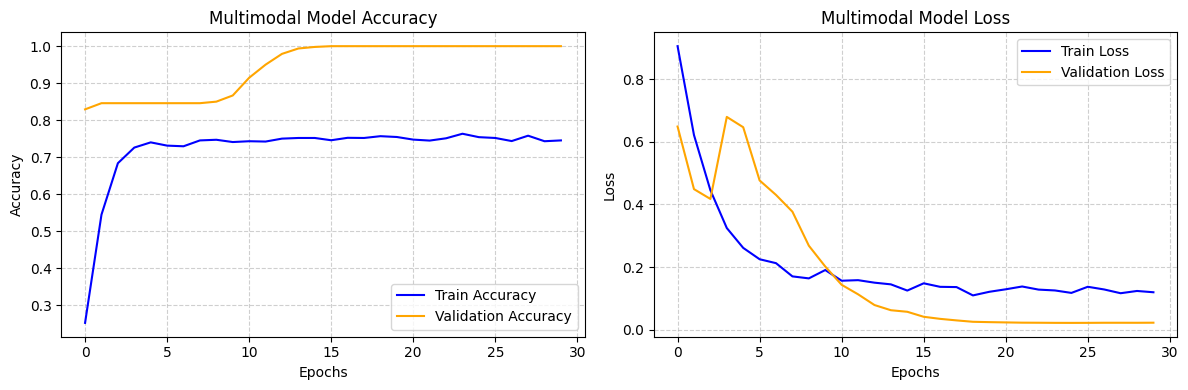

Local architecture verified! The Data Generator and Model are perfectly synced.


In [25]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Multimodal Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Multimodal Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("Local architecture verified! The Data Generator and Model are perfectly synced.")

In [26]:
def evaluate_on_test():
    print("\n--- FINAL TEST RESULTS (UNSEEN DATA) ---")
    y_true = []
    y_pred = []

    for i in range(len(test_gen)):
        (imgs, tabs), labels = test_gen[i]
        preds = local_model.predict([imgs, tabs], verbose=0)
        y_true.extend(labels)
        y_pred.extend((preds > 0.5).astype(int).flatten())

    print(classification_report(y_true, y_pred, target_names=['Healthy', 'Leukemia']))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Institution Alpha: Test Set Performance")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


--- FINAL TEST RESULTS (UNSEEN DATA) ---
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        74
    Leukemia       1.00      1.00      1.00       406

    accuracy                           1.00       480
   macro avg       1.00      1.00      1.00       480
weighted avg       1.00      1.00      1.00       480



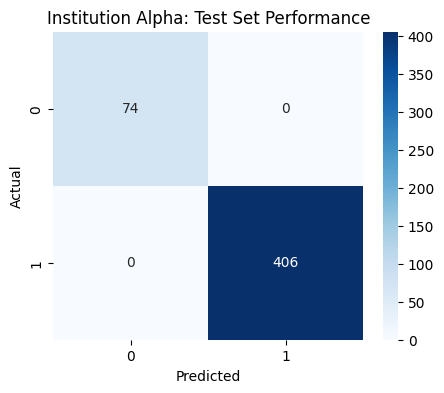

In [27]:
evaluate_on_test()